In [6]:
%load_ext autoreload
%autoreload 2
from scripts.utils import *
from scripts.gaussianclassifiers import *
from scripts.dcf import *
from scripts.logisticreg import *
from scripts.SVM import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 📘 Theory & Key Functions
**Theoretical Recall:** Support Vector Machines (SVM) find the maximum-margin hyperplane separating classes. Solving the *dual formulation* of the SVM allows us to use the **kernel trick**, replacing dot products with a kernel function $K(x,y)$ to efficiently learn complex non-linear boundaries.
- **Polynomial Kernel**: $K(x,y) = (x^T y + c)^d$. Captures feature interactions up to degree $d$.
- **RBF (Radial Basis Function)**: $K(x,y) = e^{-\gamma ||x-y||^2}$. Maps to an infinite-dimensional space, providing highly flexible, localized decision regions.

**Key Functions (from `SVM.py`):**
- `train_SVM()`: Solves the dual problem for a linear SVM.
- `train_kernel_poly_SVM()` / `train_kernel_KRB()`: Solve the dual SVM problem using Polynomial and RBF kernel functions, respectively, incorporating hyperparameters like $C$, $d$, $c$, and $\gamma$.

See the implementations in [SVM.py](../scripts/SVM.py).

In [7]:
D,L,labels=init_dataset()
(DTR, LTR), (DVAL, LVAL)=split_db_2to1(D,L)

================================= K: 1 C: 1e-05==============================================================
Primal Loss : 0.04 - Dual Loss : -0.0
Error Rate: 50.4%
DCF min: 1.0
Actual DCF:1.0

================================= K: 1 C: 3.1622776601683795e-05==============================================================
Primal Loss : 0.1193533458381456 - Dual Loss : 0.11935334583814564
Error Rate: 9.2%
DCF min: 0.36199116743471577
Actual DCF:1.0

================================= K: 1 C: 0.0001==============================================================
Primal Loss : 0.3290170090801559 - Dual Loss : 0.329017009080156
Error Rate: 9.2%
DCF min: 0.36397529441884274
Actual DCF:1.0

================================= K: 1 C: 0.00031622776601683794==============================================================
Primal Loss : 0.7734635862222929 - Dual Loss : 0.7734635848556489
Error Rate: 9.2%
DCF min: 0.36199116743471577
Actual DCF:0.9990079365079365

================================= K: 1 C:

Text(0, 0.5, 'DCF value')

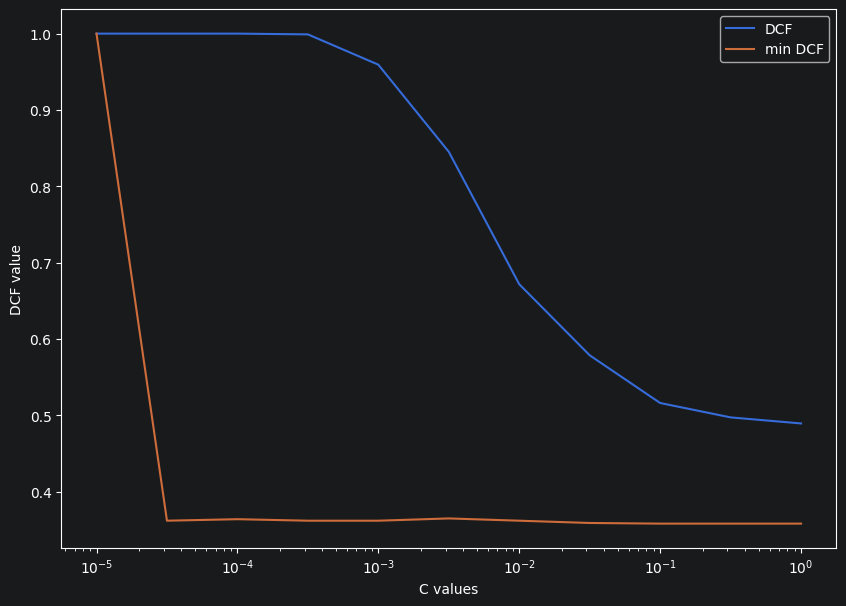

In [8]:
C=np.logspace(-5, 0, 11)
dcf=[]
mindcf=[]
pi_T=0.1
for c in C:
    print(f"================================= K: {1} C: {c}==============================================================")
    alpha,w,b=train_SVM(DTR,LTR,c,1)
    s=w.T @ DVAL + b
    predictions=s >0
    error_rate=np.mean(predictions != LVAL)
    min_dcf=compute_min_dcf(s,LVAL,pi_T,1,1)

    predictions_bayes = get_bayes_decision(s, pi_T, 1, 1)
    act_dcf = DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)
    dcf.append(act_dcf)
    mindcf.append(min_dcf)

    print(f"Error Rate: {error_rate * 100:.1f}%")
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")

    print(f"==================================================================================================")


plt.figure(figsize=(10, 7))
plt.xscale('log')
plt.plot(C, dcf, label='DCF')
plt.plot(C, mindcf, label='min DCF')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

Observation with DTR Centered
================================= K: 1 C: 1e-05==============================================================
Primal Loss : 0.04 - Dual Loss : -0.0
Error Rate: 50.4%
DCF min: 1.0
Actual DCF:1.0

================================= K: 1 C: 3.1622776601683795e-05==============================================================
Primal Loss : 0.11935315604413956 - Dual Loss : 0.1193531560441396
Error Rate: 9.2%
DCF min: 0.36199116743471577
Actual DCF:1.0

================================= K: 1 C: 0.0001==============================================================
Primal Loss : 0.32901561947240576 - Dual Loss : 0.3290156194724059
Error Rate: 9.2%
DCF min: 0.36397529441884274
Actual DCF:1.0

================================= K: 1 C: 0.00031622776601683794==============================================================
Primal Loss : 0.7734422455643782 - Dual Loss : 0.7734422455643786
Error Rate: 9.3%
DCF min: 0.36298323092677925
Actual DCF:0.9990079365079365

=========

Text(0, 0.5, 'DCF value')

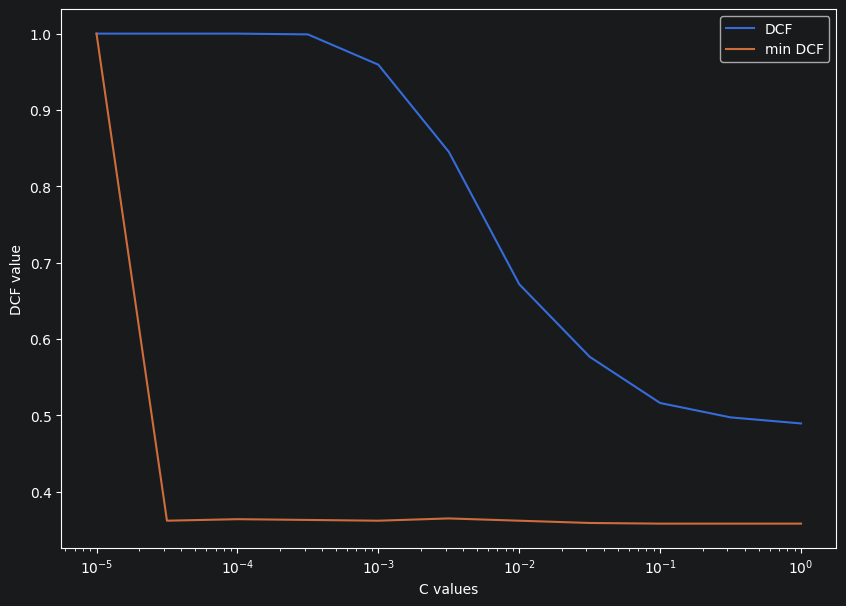

In [9]:
mean=vCol(getMu(DTR))
DTR_centered=DTR-mean
DVAL_centered=DVAL-mean
C=np.logspace(-5, 0, 11)
dcf=[]
mindcf=[]
pi_T=0.1
print("Observation with DTR Centered")
for c in C:
   

    print(f"================================= K: {1} C: {c}==============================================================")
    alpha,w,b=train_SVM(DTR_centered,LTR,c,1)
    s=w.T @ DVAL_centered + b
    predictions=s >0
    error_rate=np.mean(predictions != LVAL)
    min_dcf=compute_min_dcf(s,LVAL,pi_T,1,1)

    predictions_bayes = get_bayes_decision(s, pi_T, 1, 1)
    act_dcf = DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)
    dcf.append(act_dcf)
    mindcf.append(min_dcf)

    print(f"Error Rate: {error_rate * 100:.1f}%")
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")

    print(f"==================================================================================================")


plt.figure(figsize=(10, 7))
plt.xscale('log')
plt.plot(C, dcf, label='DCF')
plt.plot(C, mindcf, label='min DCF')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

================================= K: 0 Poly d=2==============================================================
================================= c=1e-05==============================================================
Primal Loss : 0.04 - Dual Loss : -0.0
Error Rate: 50.4%
DCF min: 1.0
Actual DCF:1.0

================================= c=3.1622776601683795e-05==============================================================
Primal Loss : 0.10765596015908384 - Dual Loss : 0.10765595990800816
Error Rate: 7.8%
DCF min: 0.24548771121351765
Actual DCF:1.0

================================= c=0.0001==============================================================
Primal Loss : 0.25444498918892544 - Dual Loss : 0.2544449871690707
Error Rate: 7.4%
DCF min: 0.2512960829493087
Actual DCF:1.0

================================= c=0.00031622776601683794==============================================================
Primal Loss : 0.5636608281250338 - Dual Loss : 0.5636608188562164
Error Rate: 7.2%
DCF min: 0.25

Text(0, 0.5, 'DCF value')

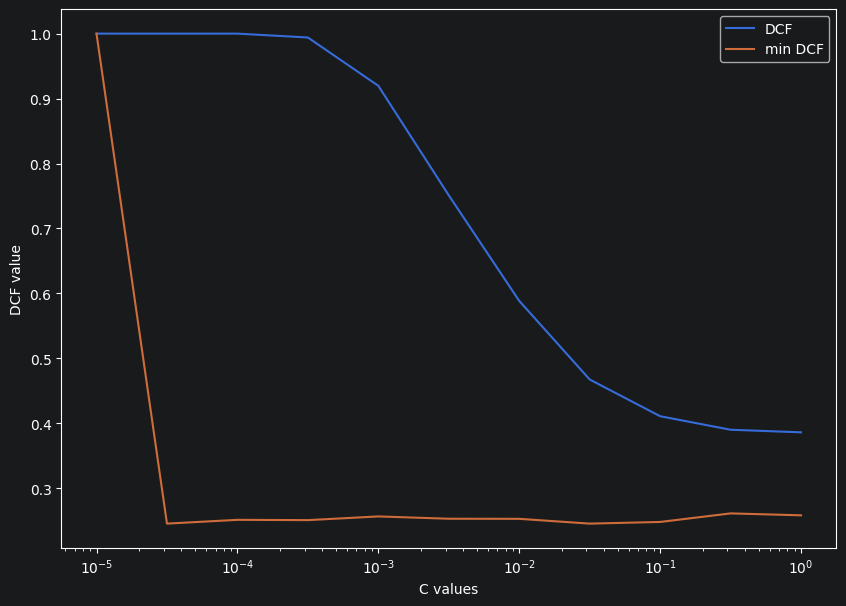

In [10]:
d=2
xi=0
pi_T=0.1
K=0
C=np.logspace(-5, 0, 11)
ZTR=LTR*2-1
dcf=[]
mindcf=[]

print(f"================================= K: {K} Poly d={d}==============================================================")
for c in C:
    print(f"================================= c={c}==============================================================")
    alpha=train_kernel_poly_SVM(c,DTR,LTR,xi,d,1)
    reg_kernel=regular_kernel(polygrad_d(d,DTR,DVAL,1),xi)
    s=alpha*ZTR @ reg_kernel
    predictions=s >0
    error_rate=np.mean(predictions != LVAL)
    min_dcf=compute_min_dcf(s,LVAL,pi_T,1,1)

    predictions_bayes = get_bayes_decision(s, pi_T, 1, 1)
    act_dcf = DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)

    dcf.append(act_dcf)
    mindcf.append(min_dcf)

    print(f"Error Rate: {error_rate * 100:.1f}%")
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")


plt.figure(figsize=(10, 7))
plt.xscale('log')
plt.plot(C, dcf, label='DCF')
plt.plot(C, mindcf, label='min DCF')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

================================= K: 0 KRB ==============================================================
================================= c=0.001 gamma=0.01831563888873418 ==============================================================
Primal Loss : 3.7942925691399236 - Dual Loss : 3.794292569139926
Error Rate: 9.9%
DCF min: 0.3568868407578085
Actual DCF: 1.0

================================= c=0.0031622776601683794 gamma=0.01831563888873418 ==============================================================
Primal Loss : 10.592953722845865 - Dual Loss : 10.592953722845861
Error Rate: 9.6%
DCF min: 0.3568868407578085
Actual DCF: 1.0

================================= c=0.01 gamma=0.01831563888873418 ==============================================================
Primal Loss : 24.721582518002357 - Dual Loss : 24.721582355072265
Error Rate: 8.8%
DCF min: 0.34597414234511004
Actual DCF: 1.0

================================= c=0.03162277660168379 gamma=0.01831563888873418 ====================

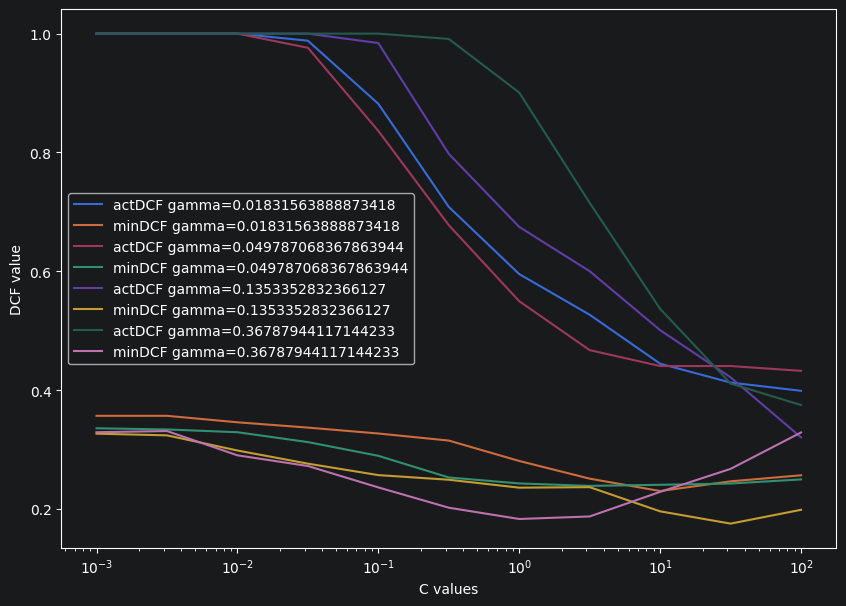

In [11]:
d=2
xi=1
pi_T=0.1
K=0
C=np.logspace(-3, 2, 11)
gammas=np.exp(np.array([-4,-3,-2,-1]))
ZTR=LTR*2-1

best_res=[None, None]  # [C, gamma]
best_dcf=[np.inf, np.inf]  # [minDCF, actDCF]

print(f"================================= K: {K} KRB ==============================================================")
plt.figure(figsize=(10, 7))
for g in gammas:
    dcf=[]
    mindcf=[]
    
    for c in C:
        print(f"================================= c={c} gamma={g} ==============================================================")
        alpha=train_kernel_KRB(K, c, DTR, LTR, xi, g)
        reg_kernel=regular_kernel(KRB(DTR, DVAL, g), xi)
        s=alpha*ZTR @ reg_kernel
        predictions=s > 0
        error_rate=np.mean(predictions != LVAL)
        min_dcf=compute_min_dcf(s, LVAL, pi_T, 1, 1)

        predictions_bayes=get_bayes_decision(s, pi_T, 1, 1)
        act_dcf=DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)

        dcf.append(act_dcf)
        mindcf.append(min_dcf)

        print(f"Error Rate: {error_rate * 100:.1f}%")
        print(f"DCF min: {min_dcf}")
        print(f"Actual DCF: {act_dcf}\n")

        if (min_dcf < best_dcf[0]) or (min_dcf == best_dcf[0] and act_dcf < best_dcf[1]):
            best_dcf[0]=min_dcf
            best_dcf[1]=act_dcf
            best_res[0]=c
            best_res[1]=g

    plt.plot(C, dcf, label=f'actDCF gamma={g}')
    plt.plot(C, mindcf, label=f'minDCF gamma={g}')

plt.xscale('log')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

print(
    f"Migliore combinazione: C={best_res[0]}, gamma={best_res[1]}, "
    f"minDCF={best_dcf[0]}, actDCF={best_dcf[1]}"
)

Let's save the best result we have, again because we will need it later.

In [10]:
d=2
xi=1
pi_T=0.1
K=0
c=31.622776601683793
g=0.1353352832366127
ZTR=LTR*2-1
alpha=train_kernel_KRB(K, c, DTR, LTR, xi, g)
reg_kernel=regular_kernel(KRB(DTR, DVAL, g), xi)
score_svm_poly=alpha*ZTR @ reg_kernel


np.save('llr/score_svm_best.npy', score_svm_poly)

Primal Loss : 12098.69532520933 - Dual Loss : 12098.64798933205
